# Section 6: Productionalize the Machine Learning Model --> Chapter 20. Deploy & Monitor Models

---
---

**Book: Applied Machine Learning for Data Science Practitioners**
<BR>

**Author:** Vidya Subramanian (https://www.linkedin.com/in/vidyas/)

**Note:** Code is only included here for the steps that require it. Please refer to the book for the complete set of steps related to the goals covered in the chapter.

---
---

---

☑ **Install libraries**

---

In [ ]:
# In case you need to install the relevent packages, please uncomment lines below and run (once only)

# !pip install pandas==2.0.3
# !pip install numpy==1.25.2
# !pip install matplotlib==3.7.1

---

☑ **Import libraries**

---

##2.2. How to detect drift?

###Step 1a: Detect Drifts

####################################################################################################

                                      Drift Detection in MAPE                                       

####################################################################################################



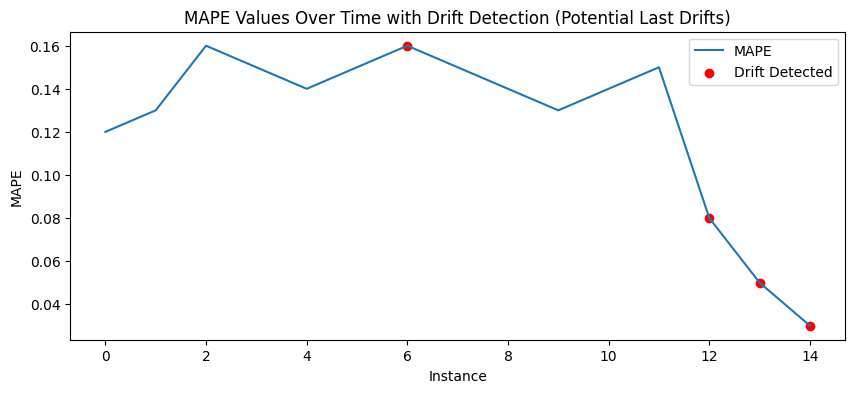

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length  * header_padding
    # Print top header border
    print("#" * title_width + "\n")
    # Print centered title
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        # Print centered subtitle
        print(subtitle.center(title_width)+ "\n")
    # Print bottom header border
    print("#" * title_width + "\n")

class DDM:
    def __init__(self, alpha, min_instances):
        # Initialize DDM parameters
        self.alpha = alpha
        self.min_instances = min_instances
        self.mean = None
        self.variance = None
        self.n = 0
        self.m = 0

    def detect_drift(self, value):
        # Increment instance count
        self.n += 1
        # Initialize mean and variance if first instance
        if self.mean is None:
            self.mean = value
            self.variance = 0
            self.m = 1
            return False

        # Update mean and variance
        old_mean = self.mean
        self.mean = old_mean + (value - old_mean) / (self.n)
        self.variance = (1 - 1 / self.n) * self.variance + self.n * (self.mean - old_mean) ** 2

        # Check if enough instances for drift detection
        if self.n < self.min_instances:
            return False

        # Calculate drift metric
        d = abs(self.mean - old_mean) / (self.variance + 1e-8) ** 0.5
        return d > self.alpha


def detect_drift():
    # Example usage:
    ddm = DDM(alpha=0.15, min_instances=5)  # Adjusted parameters

    # Simulate data stream with MAPE values (Increased drift at the end)
    mape_values = [0.12, 0.13, 0.16, 0.15, 0.14, 0.15, 0.16, 0.15, 0.14, 0.13, 0.14, 0.15, 0.08, 0.05, 0.03]

    # Initialize lists to store detected drift instances
    drift_instances = []

    # Detect drift and store instances
    for i, mape in enumerate(mape_values):
        drift_detected = ddm.detect_drift(mape)
        if drift_detected:
            drift_instances.append(i)

    # Plot MAPE values
    plt.figure(figsize=(10, 4))  # Adjust size here
    plt.plot(range(len(mape_values)), mape_values, label='MAPE')

    # Mark drift instances
    for instance in drift_instances:
        plt.scatter(instance, mape_values[instance], color='red')

    # Add a label for drift instances outside the loop
    plt.scatter([], [], color='red', label='Drift Detected')

    plt.xlabel('Instance')
    plt.ylabel('MAPE')
    plt.title('MAPE Values Over Time with Drift Detection (Potential Last Drifts)')
    plt.legend()
    plt.grid(False)  # Remove grid
    plt.show()


# Define Main Workflow
def main():
    # Print header
    print_pretty_header('Drift Detection in MAPE', "")
    # Detect and visualize drift
    detect_drift()
    return

if __name__ == "__main__":
    # Call main function
    main()


------------- End of **S6_Ch20_Deploy_Monitor_Model Chapter Code** for **Applied Machine Learning for Data Science Practitioners** ------------ Vidya Subramanian ------------------